In [1]:
# ============================================================
# RANDOM FOREST
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

# Google Drive directory
PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment"

# PROJECT_DIR = r"/Users/varunsp/Developer/Applications of Artificial Intelligence for Cyber Security/PY/Assignment-2_Final"

DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "randomforest")

os.makedirs(OUTPUT_DIR, exist_ok=True)

BODMAS_NPZ = os.path.join(DATA_DIR, "bodmas.npz")
METADATA_CSV = os.path.join(DATA_DIR, "bodmas_metadata.csv")
CATEGORY_CSV = os.path.join(DATA_DIR, "bodmas_malware_category.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Data folder:", DATA_DIR)
print("Random Forest output folder:", OUTPUT_DIR)

Mounted at /content/drive
Data folder: /content/drive/MyDrive/BODMAS_Assignment/dataset
Random Forest output folder: /content/drive/MyDrive/BODMAS_Assignment/randomforest


In [2]:
# ============================================================
# LOAD DATA AND PREPARE CATEGORY LABELS
# ============================================================

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

data = np.load(BODMAS_NPZ, allow_pickle=True)
X = data["X"]

metadata = pd.read_csv(METADATA_CSV)
categories = pd.read_csv(CATEGORY_CSV)

print("NPZ keys:", list(data.keys()))
print("Feature matrix shape:", X.shape)
print("Metadata shape:", metadata.shape)
print("Category file shape:", categories.shape)

print("\nMetadata columns:", metadata.columns.tolist())
print("Category columns:", categories.columns.tolist())

# =========================
# Correct label preparation
# =========================
metadata_sha_col = "sha256" if "sha256" in metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in categories.columns else "sha"

possible_category_cols = [
    col for col in categories.columns
    if col.lower() not in ["sha", "sha256"]
]

category_label_col = possible_category_cols[0]

print("\nUsing metadata SHA column:", metadata_sha_col)
print("Using category SHA column:", category_sha_col)
print("Using malware category column:", category_label_col)

category_map = categories.set_index(category_sha_col)[category_label_col]

df = metadata.copy()
df["malware_category"] = df[metadata_sha_col].map(category_map)

# Category file does not include benign programs
df["malware_category"] = df["malware_category"].fillna("benign")

y_text = df["malware_category"].astype(str).values

print("\nFinal X shape:", X.shape)
print("Final y shape:", y_text.shape)

print("\nClass distribution:")
class_distribution = pd.Series(y_text).value_counts()
display(class_distribution)

class_distribution.to_csv(os.path.join(OUTPUT_DIR, "rf_class_distribution.csv"))

LOADING DATA
NPZ keys: ['X', 'y']
Feature matrix shape: (134435, 2381)
Metadata shape: (134435, 3)
Category file shape: (57293, 2)

Metadata columns: ['sha', 'timestamp', 'family']
Category columns: ['sha256', 'category']

Using metadata SHA column: sha
Using category SHA column: sha256
Using malware category column: category

Final X shape: (134435, 2381)
Final y shape: (134435,)

Class distribution:


,count
benign,77142
trojan,29972
worm,16697
backdoor,7331
downloader,1031
ransomware,821
dropper,715
informationstealer,448
virus,192
pua,29


In [3]:
# ============================================================
# LABEL ENCODING AND TRAIN-TEST SPLIT
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = list(label_encoder.classes_)

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Save label encoder for holdout notebook
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTesting class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Classes:
0 -> backdoor
1 -> benign
2 -> cryptominer
3 -> downloader
4 -> dropper
5 -> exploit
6 -> informationstealer
7 -> p2p-worm
8 -> pua
9 -> ransomware
10 -> rootkit
11 -> trojan
12 -> trojan-gamethief
13 -> virus
14 -> worm

Train shape: (107548, 2381)
Test shape: (26887, 2381)

Training class distribution:


,count
benign,61714
trojan,23977
worm,13358
backdoor,5865
downloader,825
ransomware,657
dropper,572
informationstealer,358
virus,153
pua,23



Testing class distribution:


,count
benign,15428
trojan,5995
worm,3339
backdoor,1466
downloader,206
ransomware,164
dropper,143
informationstealer,90
virus,39
pua,6


In [4]:
# ============================================================
# HELPER FUNCTIONS FOR EVALUATION
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    """
    TPR and FPR for each class.

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    """
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def evaluate_model(model, X_data, y_data, split_name):
    print("=" * 80)
    print(f"RANDOM FOREST EVALUATION ON {split_name.upper()}")
    print("=" * 80)

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    balanced_acc = balanced_accuracy_score(y_data, y_pred)

    print("Overall Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_data,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    tpr_fpr_df = calculate_tpr_fpr(y_data, y_pred, class_names)

    print("\nTPR and FPR per class:")
    display(tpr_fpr_df)

    return {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions": y_pred,
        "tpr_fpr": tpr_fpr_df
    }

In [5]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

# Smaller tuning subset to reduce runtime but the final training still uses full training data
TUNE_SIZE = 0.25

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning subset shape:", X_tune.shape)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 30, 50, 70],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring="balanced_accuracy",
    cv=2,
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

rf_search.fit(X_tune, y_tune)

end_time = time.time()

print("\nRandom Forest tuning completed.")
print("Tuning time:", round((end_time - start_time) / 60, 2), "minutes")
print("Best parameters:")
print(rf_search.best_params_)
print("Best CV balanced accuracy:", rf_search.best_score_)

Tuning subset shape: (26887, 2381)
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



Random Forest tuning completed.
Tuning time: 13.2 minutes
Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Best CV balanced accuracy: 0.571038205917811


In [6]:
# ============================================================
# RANDOM FOREST MODEL TRAINING
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
import joblib
import os
import time

rf_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        n_estimators=2000,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True
    ))
])

print("Training Random Forest...")

start_time = time.time()
rf_final.fit(X_train, y_train)
end_time = time.time()

print("Training time:", round((end_time - start_time) / 60, 2), "minutes")

rf_train_pred = rf_final.predict(X_train)
rf_test_pred = rf_final.predict(X_test)

print("\nRandom Forest Train Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Random Forest Train Balanced Accuracy:", balanced_accuracy_score(y_train, rf_train_pred))

print("\nRandom Forest Test Accuracy:", accuracy_score(y_test, rf_test_pred))
print("Random Forest Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_test_pred))

print("\nTest Classification Report:")
print(classification_report(
    y_test,
    rf_test_pred,
    target_names=class_names,
    zero_division=0
))

joblib.dump(rf_final, os.path.join(OUTPUT_DIR, "random_forest_model.joblib"))

print("Saved RF model to:")
print(os.path.join(OUTPUT_DIR, "random_forest_model.joblib"))

Training Random Forest...
Training time: 124.7 minutes

Random Forest Train Accuracy: 1.0
Random Forest Train Balanced Accuracy: 1.0

Random Forest Test Accuracy: 0.9703946144977127
Random Forest Test Balanced Accuracy: 0.614821788737883

Test Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      0.99     15428
       cryptominer       1.00      0.25      0.40         4
        downloader       0.93      0.83      0.88       206
           dropper       0.82      0.79      0.80       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.92      0.79      0.85        90
          p2p-worm       0.00      0.00      0.00         3
               pua       0.00      0.00      0.00         6
        ransomware       0.95      0.85      0.90       164
           rootkit       0.00      0.00      0.00         1
            

In [7]:
# ============================================================
# EVALUATING RANDOM FOREST
# ============================================================

rf_train_results = evaluate_model(
    rf_final,
    X_train,
    y_train,
    "training set"
)

rf_test_results = evaluate_model(
    rf_final,
    X_test,
    y_test,
    "testing set"
)

# Save TPR/FPR results
rf_train_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_train_tpr_fpr.csv"),
    index=False
)

rf_test_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_test_tpr_fpr.csv"),
    index=False
)

# Save summary
rf_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "split": "training",
        "accuracy": rf_train_results["accuracy"],
        "balanced_accuracy": rf_train_results["balanced_accuracy"]
    },
    {
        "model": "Random Forest",
        "split": "testing",
        "accuracy": rf_test_results["accuracy"],
        "balanced_accuracy": rf_test_results["balanced_accuracy"]
    }
])

display(rf_summary)

rf_summary.to_csv(
    os.path.join(OUTPUT_DIR, "rf_results_summary.csv"),
    index=False
)

RANDOM FOREST EVALUATION ON TRAINING SET
Overall Accuracy: 1.0
Balanced Accuracy: 1.0

Classification Report:
                    precision    recall  f1-score   support

          backdoor       1.00      1.00      1.00      5865
            benign       1.00      1.00      1.00     61714
       cryptominer       1.00      1.00      1.00        16
        downloader       1.00      1.00      1.00       825
           dropper       1.00      1.00      1.00       572
           exploit       1.00      1.00      1.00        10
informationstealer       1.00      1.00      1.00       358
          p2p-worm       1.00      1.00      1.00        13
               pua       1.00      1.00      1.00        23
        ransomware       1.00      1.00      1.00       657
           rootkit       1.00      1.00      1.00         2
            trojan       1.00      1.00      1.00     23977
  trojan-gamethief       1.00      1.00      1.00         5
             virus       1.00      1.00      1.00

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,5865,0,101683,0,1.0,0.0
1,benign,61714,0,45834,0,1.0,0.0
2,cryptominer,16,0,107532,0,1.0,0.0
3,downloader,825,0,106723,0,1.0,0.0
4,dropper,572,0,106976,0,1.0,0.0
5,exploit,10,0,107538,0,1.0,0.0
6,informationstealer,358,0,107190,0,1.0,0.0
7,p2p-worm,13,0,107535,0,1.0,0.0
8,pua,23,0,107525,0,1.0,0.0
9,ransomware,657,0,106891,0,1.0,0.0


RANDOM FOREST EVALUATION ON TESTING SET
Overall Accuracy: 0.9704
Balanced Accuracy: 0.6148

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      0.99     15428
       cryptominer       1.00      0.25      0.40         4
        downloader       0.93      0.83      0.88       206
           dropper       0.82      0.79      0.80       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.92      0.79      0.85        90
          p2p-worm       0.00      0.00      0.00         3
               pua       0.00      0.00      0.00         6
        ransomware       0.95      0.85      0.90       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.96      0.92      0.94      5995
  trojan-gamethief       0.00      0.00      0.00         1
             virus       1.00      0.87     

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,1417,88,25333,49,0.966576,0.003462
1,benign,15425,201,11258,3,0.999806,0.017541
2,cryptominer,1,0,26883,3,0.250000,0.000000
3,downloader,170,12,26669,36,0.825243,0.000450
4,dropper,113,25,26719,30,0.790210,0.000935
5,exploit,2,0,26885,0,1.000000,0.000000
6,informationstealer,71,6,26791,19,0.788889,0.000224
7,p2p-worm,0,1,26883,3,0.000000,0.000037
8,pua,0,0,26881,6,0.000000,0.000000
9,ransomware,140,7,26716,24,0.853659,0.000262


,model,split,accuracy,balanced_accuracy
0,Random Forest,training,1.000000,1.000000
1,Random Forest,testing,0.970395,0.614822


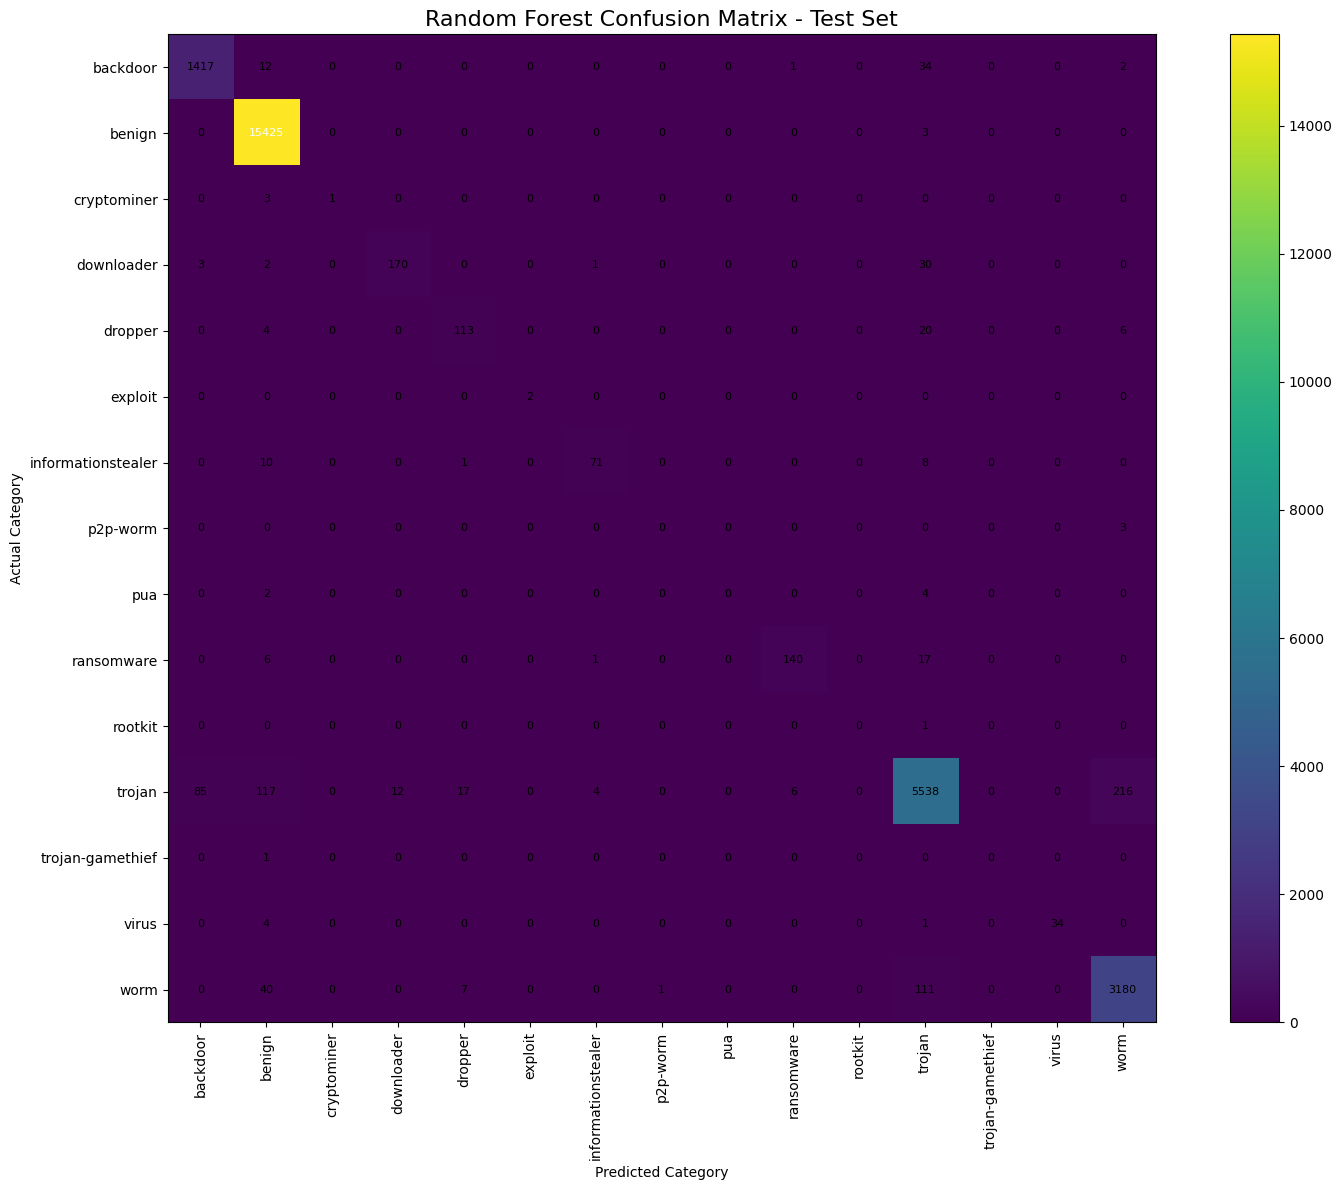

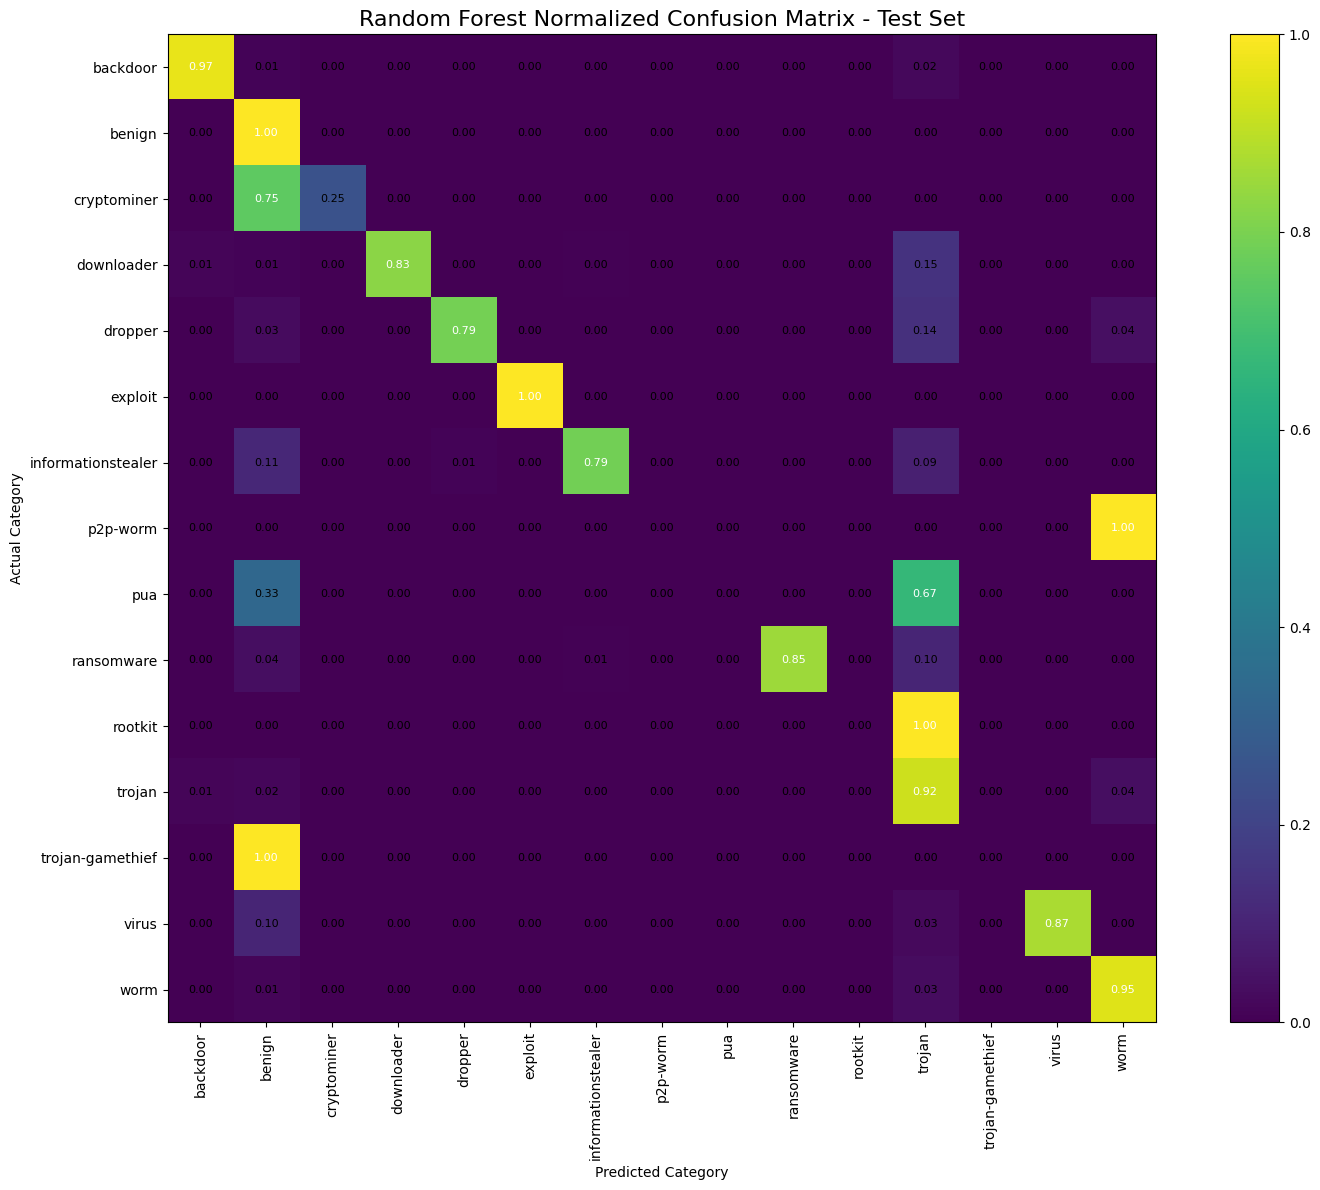

In [8]:
# ============================================================
# CONFUSION MATRIX IMAGES
# ============================================================

def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize="true"
        )
        fmt = ".2f"
    else:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels
        )
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()


# Test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Confusion Matrix - Test Set",
    normalize=False
)

# Normalized test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Normalized Confusion Matrix - Test Set",
    normalize=True
)

In [9]:
# ============================================================
# CHECK RANDOM FOREST ON REAL SAMPLE ROWS
# ============================================================

N_SAMPLES = 30
rng = np.random.default_rng(RANDOM_STATE)

sample_indices = rng.choice(X.shape[0], size=N_SAMPLES, replace=False)

X_sample = X[sample_indices]
y_sample_true = y[sample_indices]

rf_sample_pred = rf_final.predict(X_sample)

sample_results = pd.DataFrame({
    "sample_index": sample_indices,
    "sha": df.iloc[sample_indices][metadata_sha_col].values,
    "actual_category": label_encoder.inverse_transform(y_sample_true),
    "predicted_category": label_encoder.inverse_transform(rf_sample_pred),
})

sample_results["correct"] = (
    sample_results["actual_category"] == sample_results["predicted_category"]
)

display(sample_results)

sample_accuracy = accuracy_score(y_sample_true, rf_sample_pred)

print("Random Forest accuracy on selected samples:", round(sample_accuracy, 4))
print("Correct predictions:", sample_results["correct"].sum(), "/", N_SAMPLES)

,sample_index,sha,actual_category,predicted_category,correct
0,86555,f61e47ff46c2029eb735df3d1eb6243196d4421c4ddc77...,benign,benign,True
1,70767,37f04f611715c86b6225faa7db02078f678a1ab086795b...,trojan,trojan,True
2,58201,8eb1bc75eea45ab42df04f28f80865bb5d8fa2c7d87e41...,worm,worm,True
3,115405,792d9e48ead3ace6282e25877450e9bda0bdedd066d93e...,benign,benign,True
4,11995,62ac3e52f1645ad2f35c3024b528f1f2902129221aef48...,benign,benign,True
5,12658,7a56ddb4e7fcc728286dc2d9dafcc0b869a50762b7d579...,benign,benign,True
6,24539,8e0ddde2f1456dc3f4bb5fa7d27a6c95d61726e67f8872...,trojan,trojan,True
7,110606,fb35b311e6ab34db6748d605662114cbd20e5eefb5522b...,benign,benign,True
8,105663,f15d7d9fe1f17214735eaae84df7b2f242199255d0367c...,benign,benign,True
9,93735,535582b8385115e6f8fd963de93f3fad4e70e66c5dc047...,benign,benign,True


Random Forest accuracy on selected samples: 1.0
Correct predictions: 30 / 30


RF model: /content/drive/MyDrive/BODMAS_Assignment/randomforest/random_forest_model.joblib
Label encoder: /content/drive/MyDrive/BODMAS_Assignment/randomforest/label_encoder.joblib
Holdout NPZ: /content/drive/MyDrive/BODMAS_Assignment/HoldOutDataSet/bodmas_holdout.npz

Random Forest model loaded.
Classes: ['backdoor', 'benign', 'cryptominer', 'downloader', 'dropper', 'exploit', 'informationstealer', 'p2p-worm', 'pua', 'ransomware', 'rootkit', 'trojan', 'trojan-gamethief', 'virus', 'worm']

Holdout X shape: (34435, 2381)
Holdout metadata shape: (34435, 3)
Holdout category shape: (57293, 2)

Holdout class distribution:


,count
benign,18363
trojan,6724
worm,6145
backdoor,2666
informationstealer,217
dropper,135
ransomware,105
downloader,55
p2p-worm,13
pua,9



Encoded holdout y shape: (34435,)

Running Random Forest on holdout dataset...

RANDOM FOREST HOLDOUT RESULTS
Overall Accuracy: 0.9947
Balanced Accuracy: 0.9524

Classification Report:
                    precision    recall  f1-score   support

          backdoor       1.00      1.00      1.00      2666
            benign       1.00      1.00      1.00     18363
       cryptominer       1.00      1.00      1.00         1
        downloader       0.96      0.95      0.95        55
           dropper       0.96      0.96      0.96       135
           exploit       0.00      0.00      0.00         0
informationstealer       1.00      0.99      0.99       217
          p2p-worm       0.92      0.85      0.88        13
               pua       1.00      0.78      0.88         9
        ransomware       0.98      0.93      0.96       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.99      0.98      0.99      6724
  trojan-gamethief       1.00    

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,2655,12,31757,11,0.995874,0.000378
1,benign,18363,32,16040,0,1.000000,0.001991
2,cryptominer,1,0,34434,0,1.000000,0.000000
3,downloader,52,2,34378,3,0.945455,0.000058
4,dropper,130,5,34295,5,0.962963,0.000146
5,exploit,0,0,34435,0,0.000000,0.000000
6,informationstealer,215,1,34217,2,0.990783,0.000029
7,p2p-worm,11,1,34421,2,0.846154,0.000029
8,pua,7,0,34426,2,0.777778,0.000000
9,ransomware,98,2,34328,7,0.933333,0.000058


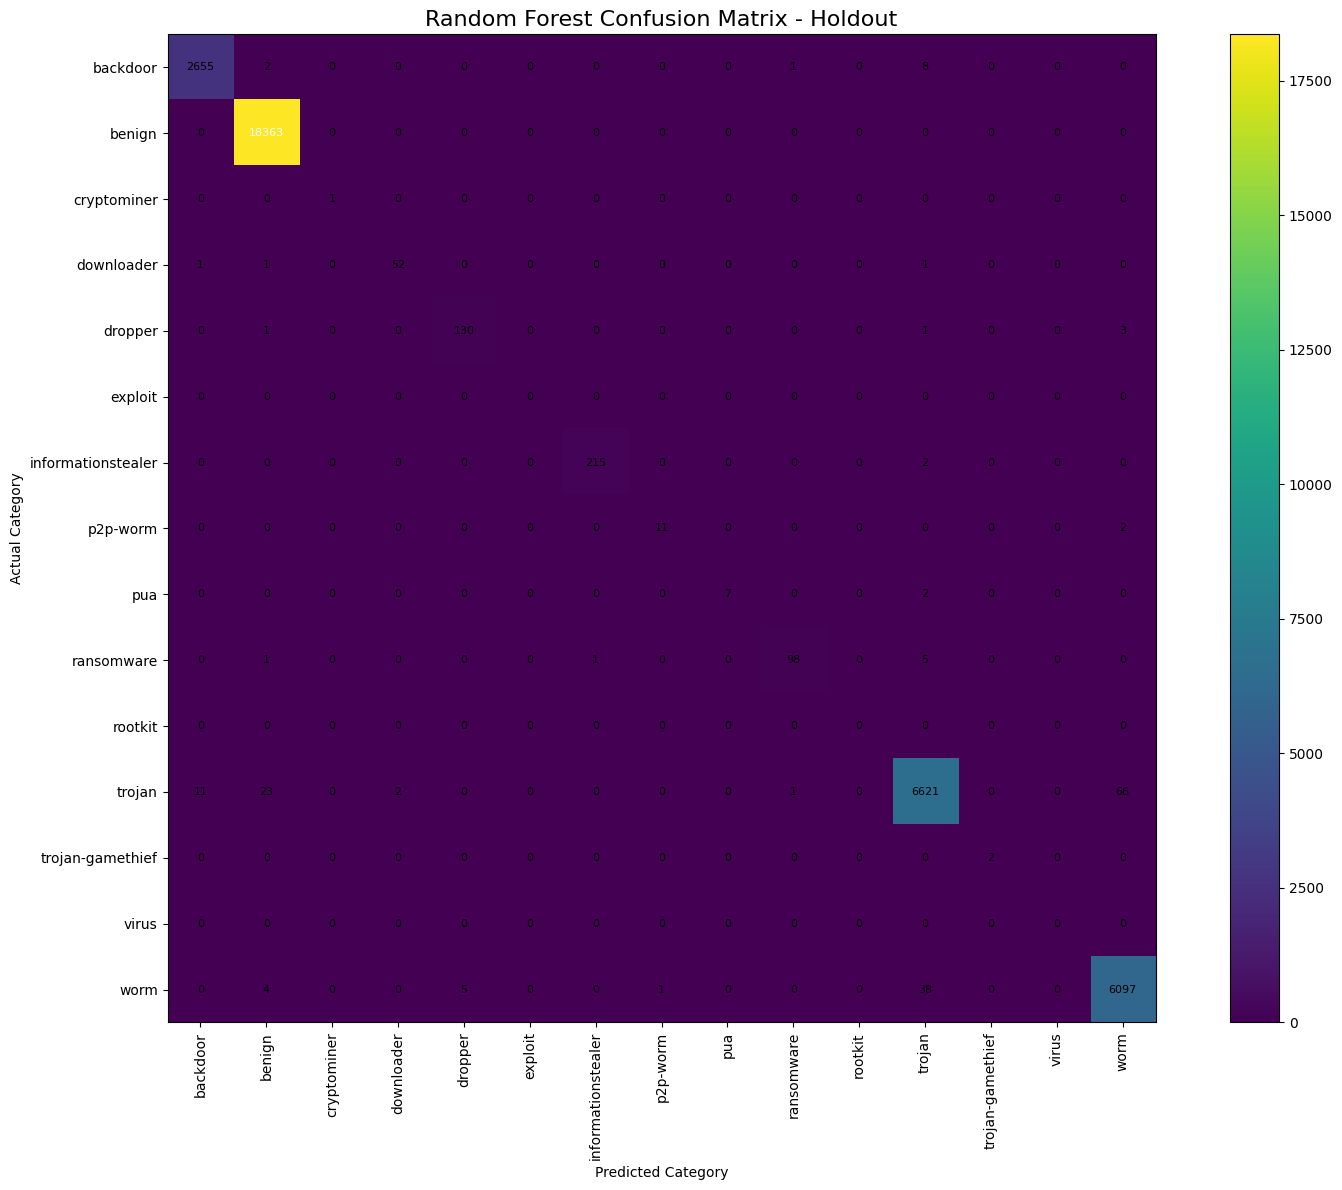

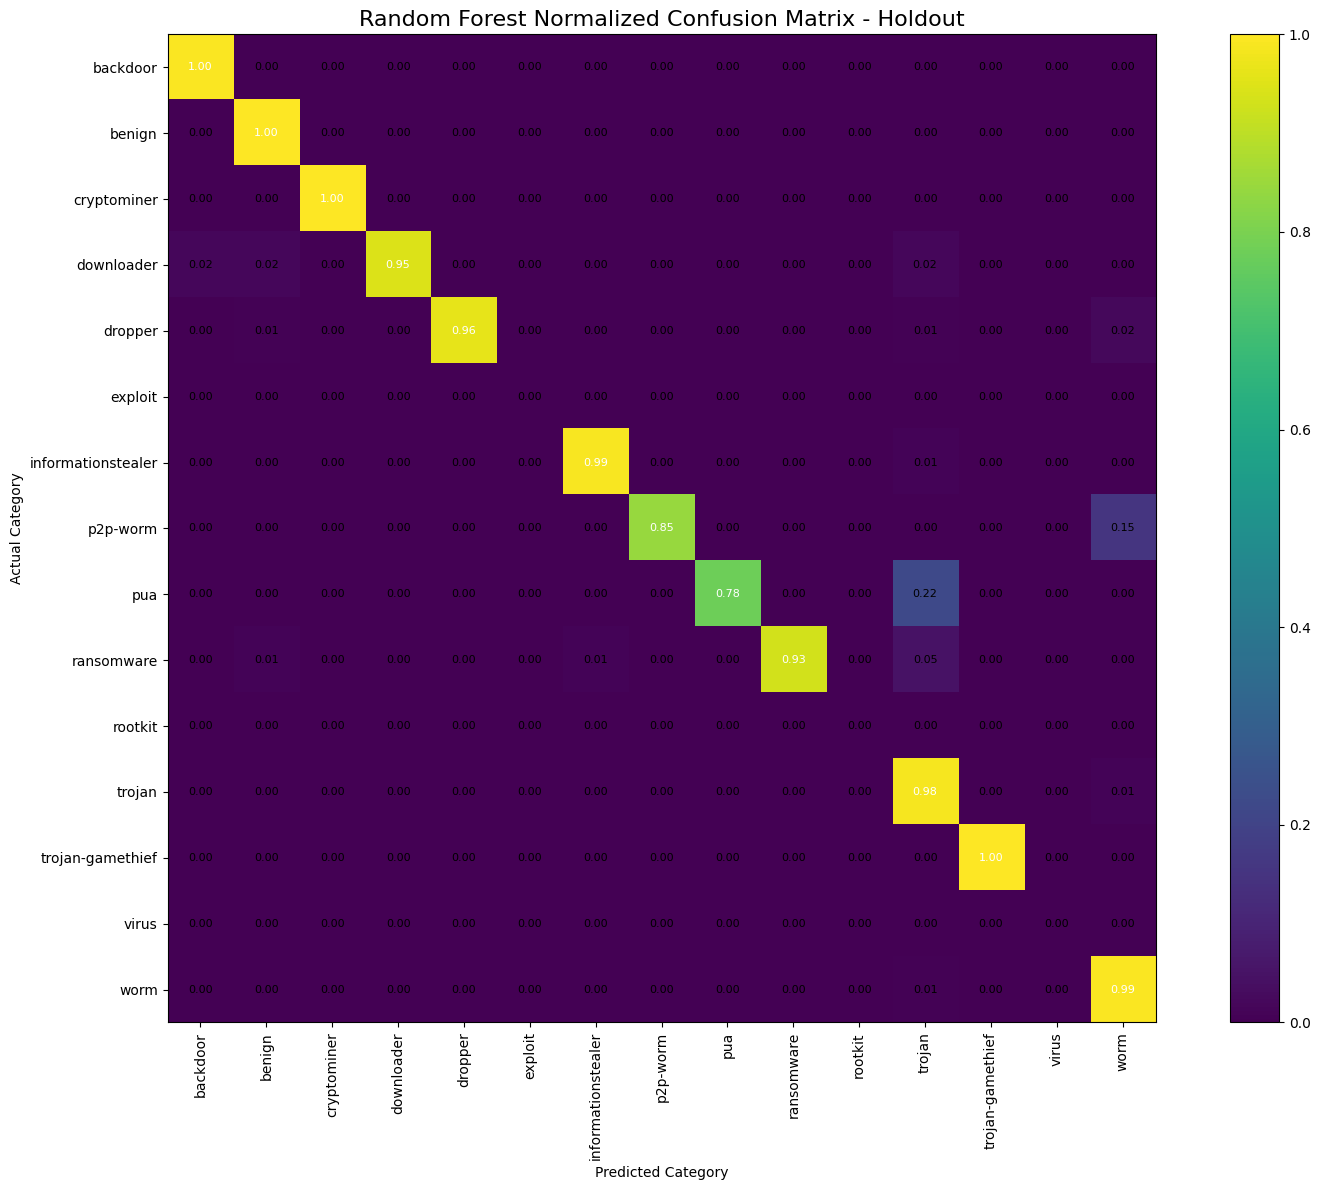

In [1]:
# ============================================================
# RANDOM FOREST - HOLDOUT DATASET EVALUATION
# NO RETRAINING, ONLY PREDICTION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment"

HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")
RF_DIR = os.path.join(PROJECT_DIR, "randomforest")

HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")
HOLDOUT_CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

RF_MODEL_PATH = os.path.join(RF_DIR, "random_forest_model.joblib")
LABEL_ENCODER_PATH = os.path.join(RF_DIR, "label_encoder.joblib")

print("RF model:", RF_MODEL_PATH)
print("Label encoder:", LABEL_ENCODER_PATH)
print("Holdout NPZ:", HOLDOUT_NPZ)

# ============================================================
# LOAD TRAINED RANDOM FOREST MODEL
# ============================================================

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

class_names = list(label_encoder.classes_)

print("\nRandom Forest model loaded.")
print("Classes:", class_names)

# ============================================================
# LOAD HOLDOUT DATA
# ============================================================

holdout_data = np.load(HOLDOUT_NPZ, allow_pickle=True)
X_holdout = holdout_data["X"]

holdout_metadata = pd.read_csv(HOLDOUT_METADATA_CSV)
holdout_categories = pd.read_csv(HOLDOUT_CATEGORY_CSV)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout metadata shape:", holdout_metadata.shape)
print("Holdout category shape:", holdout_categories.shape)

# ============================================================
# PREPARE HOLDOUT CATEGORY LABELS
# ============================================================

metadata_sha_col = "sha256" if "sha256" in holdout_metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in holdout_categories.columns else "sha"

category_label_col = [
    c for c in holdout_categories.columns
    if c.lower() not in ["sha", "sha256"]
][0]

category_map = holdout_categories.set_index(category_sha_col)[category_label_col]

holdout_df = holdout_metadata.copy()
holdout_df["malware_category"] = holdout_df[metadata_sha_col].map(category_map)

# Missing category means benign
holdout_df["malware_category"] = holdout_df["malware_category"].fillna("benign")

y_holdout_text = holdout_df["malware_category"].astype(str).values

print("\nHoldout class distribution:")
display(pd.Series(y_holdout_text).value_counts())

# Check unknown labels
unknown_classes = set(y_holdout_text) - set(class_names)

if unknown_classes:
    raise ValueError(f"Unknown classes in holdout not seen during training: {unknown_classes}")

y_holdout = label_encoder.transform(y_holdout_text)

print("\nEncoded holdout y shape:", y_holdout.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
        fmt = ".2f"
    else:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()

# ============================================================
# RANDOM FOREST HOLDOUT PREDICTION
# ============================================================

print("\nRunning Random Forest on holdout dataset...")

rf_pred = rf_model.predict(X_holdout)

rf_accuracy = accuracy_score(y_holdout, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_holdout, rf_pred)

print("\n" + "=" * 80)
print("RANDOM FOREST HOLDOUT RESULTS")
print("=" * 80)

print("Overall Accuracy:", round(rf_accuracy, 4))
print("Balanced Accuracy:", round(rf_balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    rf_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

rf_tpr_fpr = calculate_tpr_fpr(y_holdout, rf_pred, class_names)

print("\nTPR and FPR per class:")
display(rf_tpr_fpr)

# Confusion matrix images
plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Confusion Matrix - Holdout",
    normalize=False
)

plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Normalized Confusion Matrix - Holdout",
    normalize=True
)
